In [1]:
# ── Imports ──────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pyulog import ULog
import numpy as np

# Config
plt.style.use('dark_background')
LOG_PATH = '../data/logs/log_0_2026-6-7-21-00-04.ulg'

print("✅ Libraries loaded")

Matplotlib is building the font cache; this may take a moment.


✅ Libraries loaded


In [3]:
# ── Cargar el log ─────────────────────────────────────────
ulog = ULog(LOG_PATH)

# Duración real desde los datos de posición
pos = ulog.get_dataset('vehicle_local_position')
t = pos.data['timestamp']
duration = (t[-1] - t[0]) / 1e6

print(f"✅ Log cargado")
print(f"   Duración: {duration:.1f} segundos ({duration/60:.1f} minutos)")
print(f"   Topics disponibles: {len(ulog.data_list)}")

✅ Log cargado
   Duración: 308.1 segundos (5.1 minutos)
   Topics disponibles: 89


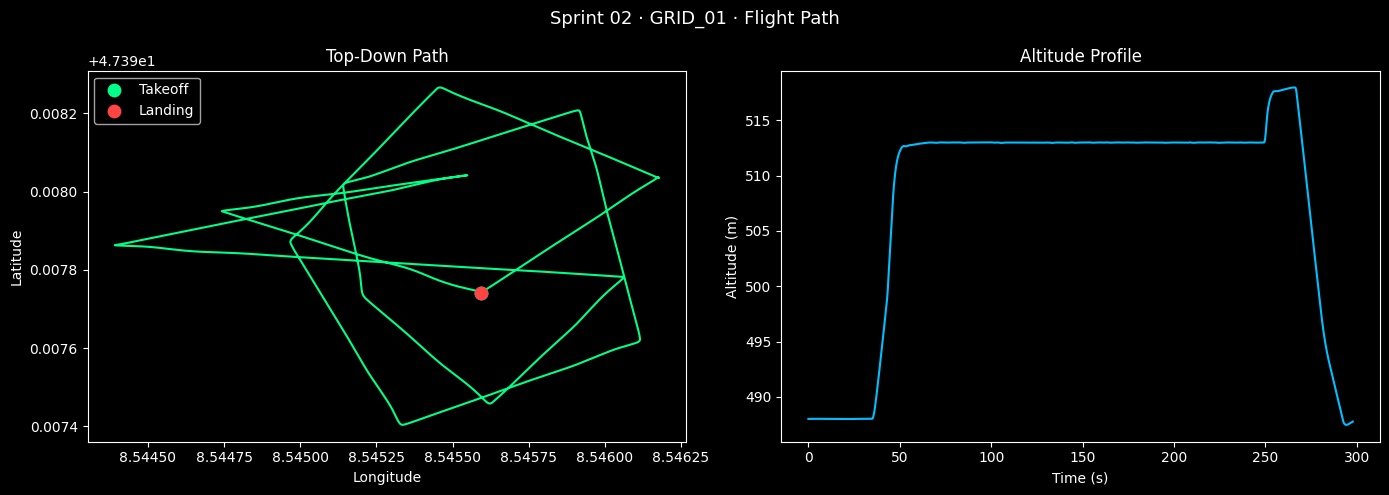

✅ Flight path generado


In [5]:
# ── Trayectoria de vuelo ──────────────────────────────────
gps = ulog.get_dataset('vehicle_global_position')
t_gps = (gps.data['timestamp'] - gps.data['timestamp'][0]) / 1e6
lat = gps.data['lat']
lon = gps.data['lon']
alt = gps.data['alt']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sprint 02 · GRID_01 · Flight Path', fontsize=13, color='white')

axes[0].plot(lon, lat, color='#00FF88', linewidth=1.5)
axes[0].scatter(lon[0], lat[0], color='#00FF88', s=80, zorder=5, label='Takeoff')
axes[0].scatter(lon[-1], lat[-1], color='#FF4444', s=80, zorder=5, label='Landing')
axes[0].set_title('Top-Down Path', color='white')
axes[0].set_xlabel('Longitude', color='white')
axes[0].set_ylabel('Latitude', color='white')
axes[0].legend()
axes[0].tick_params(colors='white')

axes[1].plot(t_gps, alt, color='#00BFFF', linewidth=1.5)
axes[1].set_title('Altitude Profile', color='white')
axes[1].set_xlabel('Time (s)', color='white')
axes[1].set_ylabel('Altitude (m)', color='white')
axes[1].tick_params(colors='white')

plt.tight_layout()
plt.savefig('../data/flight_path_grid01.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Flight path generado")

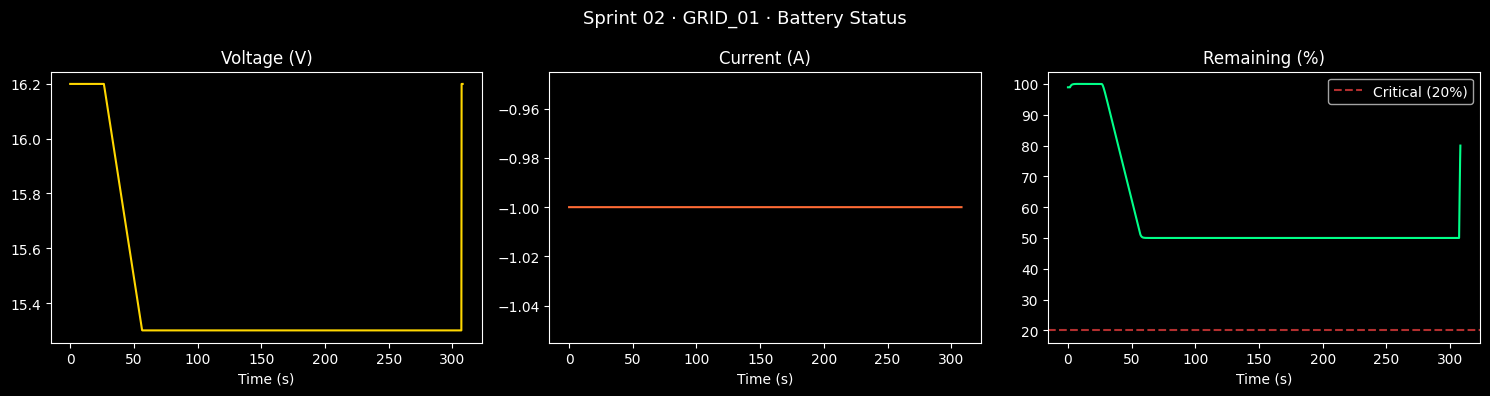

✅ Battery status generado
   Voltaje inicial: 16.20V → final: 16.20V
   Batería restante al aterrizar: 80.0%


In [8]:
# ── Battery Status ────────────────────────────────────────
bat = ulog.get_dataset('battery_status')
t_bat = (bat.data['timestamp'] - bat.data['timestamp'][0]) / 1e6
voltage = bat.data['voltage_v']
current = bat.data['current_a']
remaining = bat.data['remaining'] * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Sprint 02 · GRID_01 · Battery Status', fontsize=13, color='white')

axes[0].plot(t_bat, voltage, color='#FFD700', linewidth=1.5)
axes[0].set_title('Voltage (V)', color='white')
axes[0].set_xlabel('Time (s)', color='white')
axes[0].tick_params(colors='white')

axes[1].plot(t_bat, current, color='#FF6B35', linewidth=1.5)
axes[1].set_title('Current (A)', color='white')
axes[1].set_xlabel('Time (s)', color='white')
axes[1].tick_params(colors='white')

axes[2].plot(t_bat, remaining, color='#00FF88', linewidth=1.5)
axes[2].axhline(y=20, color='#FF4444', linestyle='--', alpha=0.7, label='Critical (20%)')
axes[2].set_title('Remaining (%)', color='white')
axes[2].set_xlabel('Time (s)', color='white')
axes[2].legend()
axes[2].tick_params(colors='white')

plt.tight_layout()
plt.savefig('../data/battery_grid01.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Battery status generado")
print(f"   Voltaje inicial: {voltage[0]:.2f}V → final: {voltage[-1]:.2f}V")
print(f"   Batería restante al aterrizar: {remaining[-1]:.1f}%")

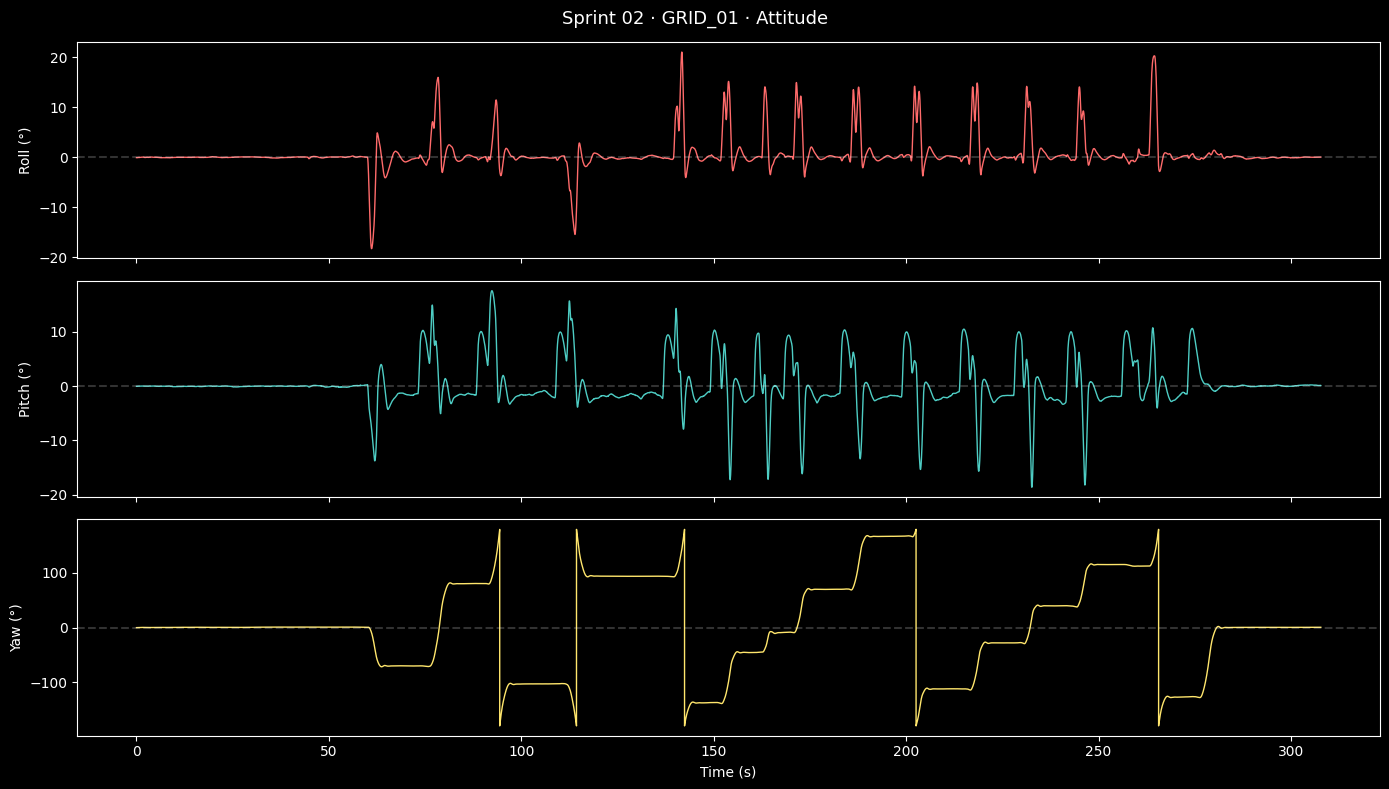

✅ Attitude generado


In [9]:
# ── Attitude (Roll / Pitch / Yaw) ─────────────────────────
att = ulog.get_dataset('vehicle_attitude')
t_att = (att.data['timestamp'] - att.data['timestamp'][0]) / 1e6

# Convertir quaterniones a grados
q0 = att.data['q[0]']
q1 = att.data['q[1]']
q2 = att.data['q[2]']
q3 = att.data['q[3]']

roll  = np.degrees(np.arctan2(2*(q0*q1 + q2*q3), 1 - 2*(q1**2 + q2**2)))
pitch = np.degrees(np.arcsin(np.clip(2*(q0*q2 - q3*q1), -1, 1)))
yaw   = np.degrees(np.arctan2(2*(q0*q3 + q1*q2), 1 - 2*(q2**2 + q3**2)))

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Sprint 02 · GRID_01 · Attitude', fontsize=13, color='white')

for ax, data, label, color in zip(
    axes,
    [roll, pitch, yaw],
    ['Roll (°)', 'Pitch (°)', 'Yaw (°)'],
    ['#FF6B6B', '#4ECDC4', '#FFE66D']
):
    ax.plot(t_att, data, color=color, linewidth=1)
    ax.set_ylabel(label, color='white')
    ax.tick_params(colors='white')
    ax.axhline(y=0, color='white', linestyle='--', alpha=0.2)

axes[-1].set_xlabel('Time (s)', color='white')
plt.tight_layout()
plt.savefig('../data/attitude_grid01.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Attitude generado")

In [10]:
# ── Mission Summary ───────────────────────────────────────
max_alt = alt.max()
min_alt = alt.min()
total_distance = np.sum(np.sqrt(np.diff(lat)**2 + np.diff(lon)**2)) * 111139

yaw_range = yaw.max() - yaw.min()
roll_max = np.abs(roll).max()
pitch_max = np.abs(pitch).max()

summary = f"""
╔══════════════════════════════════════════╗
║     SPRINT 02 · GRID_01 · SUMMARY        ║
╠══════════════════════════════════════════╣
║  Duration        : {duration:.1f}s ({duration/60:.1f} min)      
║  Max Altitude    : {max_alt:.1f}m             
║  Min Altitude    : {min_alt:.1f}m             
║  Est. Distance   : {total_distance:.1f}m          
║  Max Roll        : {roll_max:.1f}°            
║  Max Pitch       : {pitch_max:.1f}°            
║  Yaw Range       : {yaw_range:.1f}°            
║  Battery End     : {remaining[-1]:.1f}%           
║  Dropouts        : 0                     
║  PX4 Version     : v1.18.0 SITL          
╚══════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════╗
║     SPRINT 02 · GRID_01 · SUMMARY        ║
╠══════════════════════════════════════════╣
║  Duration        : 308.1s (5.1 min)      
║  Max Altitude    : 518.0m             
║  Min Altitude    : 487.5m             
║  Est. Distance   : 1194.9m          
║  Max Roll        : 21.0°            
║  Max Pitch       : 18.7°            
║  Yaw Range       : 359.9°            
║  Battery End     : 80.0%           
║  Dropouts        : 0                     
║  PX4 Version     : v1.18.0 SITL          
╚══════════════════════════════════════════╝



In [11]:
# ── Export note ───────────────────────────────────────────
print("✅ Notebook completo")
print("   Para exportar a HTML corre en terminal:")
print("   jupyter nbconvert --to html notebooks/sprint02_grid01_analysis.ipynb")

✅ Notebook completo
   Para exportar a HTML corre en terminal:
   jupyter nbconvert --to html notebooks/sprint02_grid01_analysis.ipynb
